# 04 — Experimentos comparativos de inhibición Renshaw

Se compara **el mismo circuito** bajo cuatro magnitudes de `W_R_to_MN`. Input, tamaños, parámetros base, ruido, conectividad aleatoria, semilla, duración y `dt` permanecen constantes. En el escenario control se desconecta la inhibición; las Renshaw pueden seguir activándose, pero su corriente no se resta a las motoneuronas.

## Por qué esta comparación es un experimento controlado

Los cuatro escenarios conservan:

- input motor;
- tamaños de los pools;
- parámetros base y nivel de heterogeneidad;
- ruido;
- máscaras de conectividad;
- duración, `dt` y semilla.

Solo cambia el peso `R → MN`. Por eso una diferencia entre escenarios puede atribuirse dentro del modelo a la intensidad de esa vía, y no a otro sorteo aleatorio.

Una sola semilla describe una realización. Para afirmar robustez conviene repetir todas las condiciones con varias semillas y mostrar media, desviación estándar o distribuciones.

In [6]:
from pathlib import Path
import sys

# Funciona si el kernel inicia en la raíz o dentro de notebooks/.
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import ipywidgets as widgets
from IPython.display import HTML, display, clear_output

from src.metrics import force_summary, neural_summary, population_activity
from src.muscle import normalize_force, spikes_to_force
from src.renshaw import simulate_renshaw_circuit
from src.visualization import animate_muscle_contraction, plot_raster, plot_renshaw_circuit, spike_times_from_matrix


In [7]:
BASE = dict(
    n_motor=20, n_renshaw=5, amplitude=12.0, input_type="motor_plan",
    parameter_noise=.03, input_noise=.5, p_mn_to_r=.5, w_mn_to_r=1.5,
    p_r_to_mn=.6, synaptic_tau=10., total_time=1000., dt=.5, seed=42,
)
SCENARIOS = {
    "Sin inhibición": dict(w_r_to_mn=0.0, recurrent_inhibition=False),
    "Débil": dict(w_r_to_mn=0.5, recurrent_inhibition=True),
    "Moderada": dict(w_r_to_mn=1.5, recurrent_inhibition=True),
    "Fuerte": dict(w_r_to_mn=4.0, recurrent_inhibition=True),
}

results = {}
rows = []
for name, change in SCENARIOS.items():
    result = simulate_renshaw_circuit(**BASE, **change)
    results[name] = result
    row = neural_summary(result["spikes_MN"], result["time"], result["I_R_to_MN"])
    row.update({"escenario": name, "peso_R_a_MN": change["w_r_to_mn"]})
    rows.append(row)

comparison = pd.DataFrame(rows).set_index("escenario")
comparison


,spikes_totales,firing_rate_medio_Hz,motoneuronas_activas,pico_actividad,corriente_inhibitoria_media,ISI_medio_ms,variabilidad_ISI_ms,peso_R_a_MN
escenario,,,,,,,,
Sin inhibición,311,15.55,20,16,0.000000,41.285223,9.262370,0.0
Débil,304,15.20,20,14,0.284517,41.927817,7.806703,0.5
Moderada,294,14.70,20,20,0.976427,42.649635,6.936591,1.5
Fuerte,289,14.45,20,20,2.473128,44.345725,7.880579,4.0


## Qué significa cada métrica

| Métrica | Cálculo | Qué informa | Qué no informa |
|---|---|---|---|
| Spikes totales | suma de la matriz binaria | salida total del pool | distribución entre neuronas |
| Firing rate medio | spikes / neuronas / segundos | frecuencia media del ensayo completo | tasa exclusiva durante el estímulo |
| MN activas | filas con ≥1 spike | reclutamiento mínimo | intensidad de cada MN |
| Pico poblacional | máximo de spikes por bin | mayor concentración temporal | sincronía exacta; depende del bin |
| Corriente inhibitoria media | promedio de `I_R_to_MN` | nivel global de feedback | máximos o diferencias entre MN |
| ISI medio | media de intervalos intra-neurona | separación temporal típica | regularidad por sí sola |
| Variabilidad ISI | desvío estándar agrupado | dispersión de intervalos | una prueba universal de estabilidad |

Las métricas se complementan. Por ejemplo, dos escenarios pueden tener igual cantidad de spikes pero diferente distribución temporal y, por lo tanto, distinta fuerza máxima.

La corriente inhibitoria media incluye toda la duración, también los períodos sin actividad. El ISI se agrupa a partir de los intervalos intra-neurona disponibles; no se crean intervalos entre neuronas distintas.

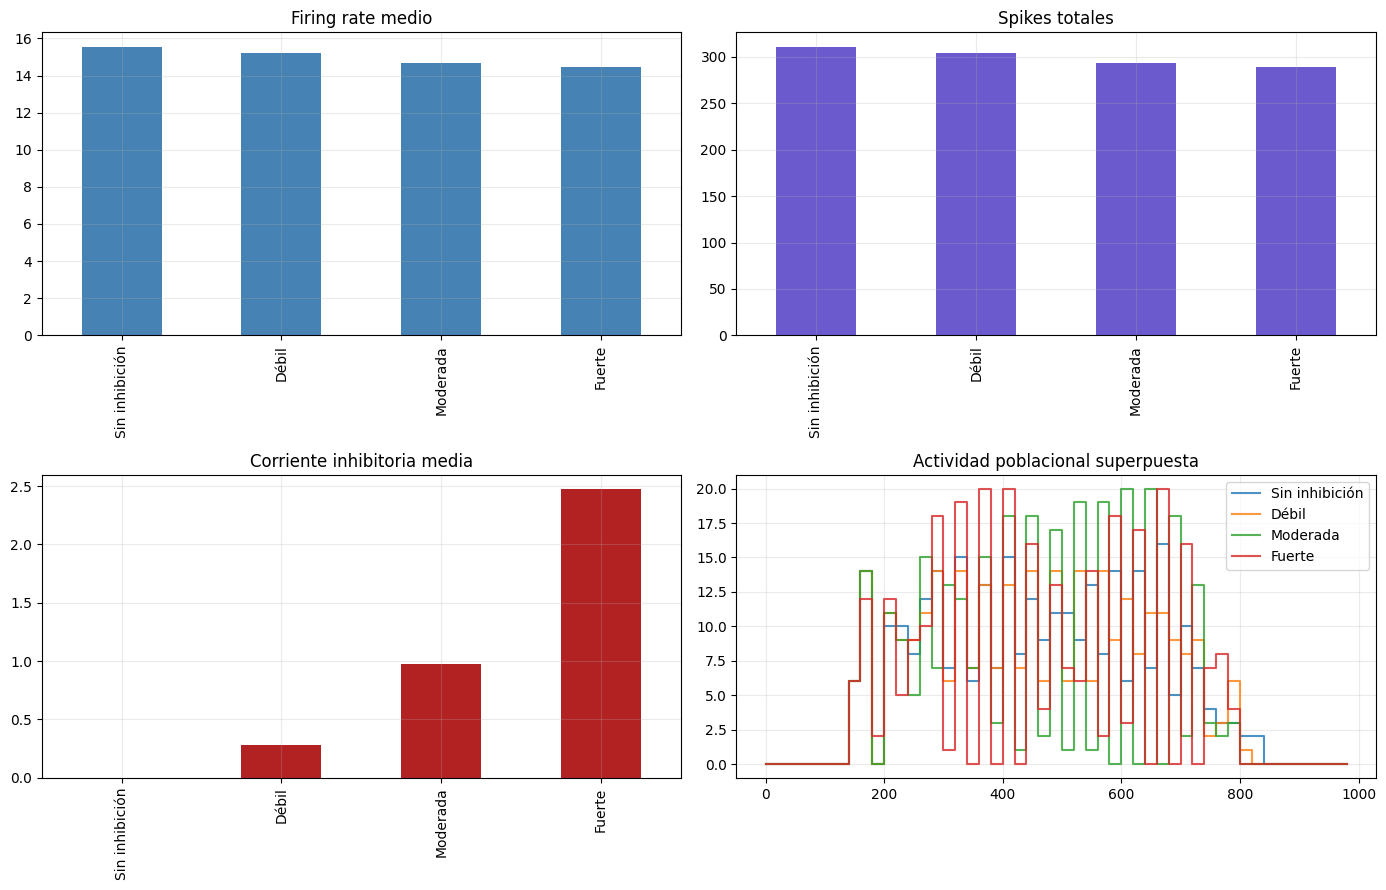

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
comparison["firing_rate_medio_Hz"].plot.bar(ax=axes[0,0], color="steelblue", title="Firing rate medio")
comparison["spikes_totales"].plot.bar(ax=axes[0,1], color="slateblue", title="Spikes totales")
comparison["corriente_inhibitoria_media"].plot.bar(ax=axes[1,0], color="firebrick", title="Corriente inhibitoria media")
for name, result in results.items():
    bins, activity = population_activity(result["spikes_MN"], result["dt"], 20)
    axes[1,1].step(bins, activity, where="post", label=name, alpha=.8)
axes[1,1].set_title("Actividad poblacional superpuesta"); axes[1,1].legend()
for ax in axes.flat:
    ax.grid(alpha=.25); ax.set_xlabel("")
fig.tight_layout(); plt.show()


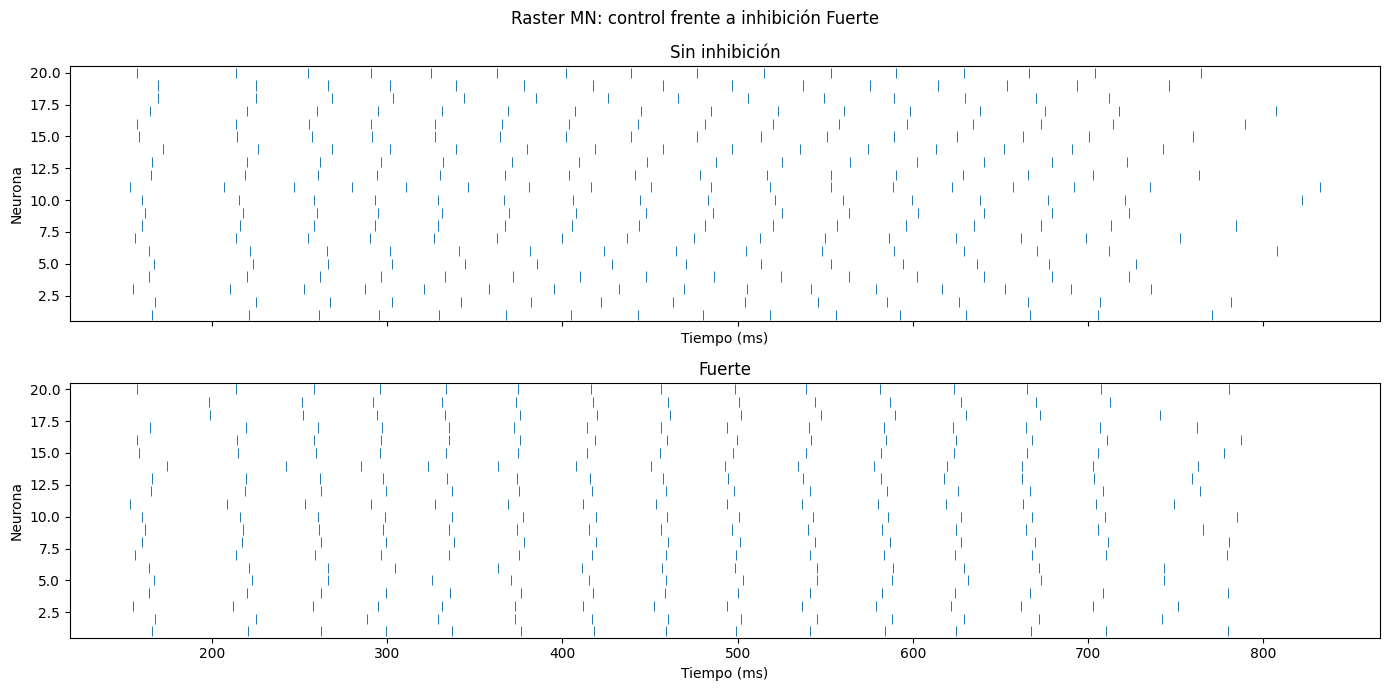

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, name in zip(axes, ["Sin inhibición", "Fuerte"]):
    result = results[name]
    plot_raster(spike_times_from_matrix(result["spikes_MN"], result["time"]), ax)
    ax.set_title(name)
fig.suptitle("Raster MN: control frente a inhibición Fuerte")
fig.tight_layout(); plt.show()


### Cómo formular la conclusión

Una conclusión válida tiene esta forma:

> “Con esta parametrización y esta semilla, aumentar el peso inhibitorio produjo X cambio en spikes, firing rate e ISI.”

Una conclusión demasiado fuerte sería:

> “Las células de Renshaw siempre estabilizan el sistema motor.”

Para generalizar se necesitan múltiples semillas, análisis de sensibilidad y parámetros con respaldo experimental. La ausencia de monotonicidad en alguna métrica no invalida el circuito: puede surgir de la interacción temporal entre spikes, feedback y bins.

## Preguntas para interpretar la ejecución

- ¿La inhibición reduce la actividad del pool motor en esta realización?
- ¿La inhibición fuerte suprime excesivamente la respuesta o aún conserva actividad?
- ¿Cómo cambian el ISI medio y su variabilidad?
- ¿Se observa una regulación progresiva al aumentar el peso?

No se presupone monotonicidad ni “mayor estabilidad”. Las respuestas deben basarse en la tabla, los rasters y las curvas que produjo esta ejecución; otra semilla o parametrización puede cambiar el patrón.